# BT4221 Project Group 4 — Spark EDA & Cleaning

**Note:** This notebook performs Exploratory Data Analysis with the raw `US_Accidents_March23.csv` file downloaded from Kaggle.  
The raw CSV or converted `US_Accidents_March23.parquet` parquet **must** be available in your local directory to successfully run this notebook.

In [1]:
# Visual helper function (Only for printing purposes)  
def border(s):
    print(f"{'='*20} {s} {'='*20}")


## Environment Setup

### Google Colab
Run if you are using Google Colab

In [2]:
# # Install Java
# !apt-get install openjdk-17-jdk-headless -qq > /dev/null

# # Download and install Spark
# !pip install pyspark

# # Install findspark
# !pip install findspark

# # Set environment variables
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# # Initialise findspark
# import findspark
# !findspark.init()

# # Verify installation
# !java -version
# !pip show pyspark
# !pip show findspark

### Windows
Run if you are using local resources (RUN ONCE)

In [3]:
# Download and install Spark
border("Install dependencies")
!pip3 install pyspark

# Install findspark
!pip3 install findspark

# Initialise findspark
import findspark
findspark.init()

# Set java version
import os
# java_path = "C:\Program Files\Java\jdk-17.0.0.1"
# os.environ['JAVA_HOME'] = java_path

# Verify installation
border("PySpark Version")
!pip show pyspark
border("findspark Version")
!pip show findspark
border("Hadoop version")
!hadoop version
border("Java version")
!java -version

==================== Install dependencies ====================
==================== PySpark Version ====================
Name: pyspark
Version: 4.1.1
Summary: Apache Spark Python API
Home-page: https://github.com/apache/spark/tree/master/python
Author: Spark Developers
Author-email: dev@spark.apache.org
License: Apache-2.0
Location: C:\Users\iiank\anaconda3\envs\spark_env\Lib\site-packages
Requires: py4j
Required-by: 
==================== findspark Version ====================
Name: findspark
Version: 2.0.1
Summary: Find pyspark to make it importable.
Home-page: https://github.com/minrk/findspark
Author: Min RK
Author-email: benjaminrk@gmail.com
License: BSD (3-clause)
Location: C:\Users\iiank\anaconda3\envs\spark_env\Lib\site-packages
Requires: 
Required-by: 
==================== Hadoop version ====================
Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on pla

openjdk version "17.0.0.1" 2024-07-02
OpenJDK Runtime Environment (build 17.0.0.1+2-3)
OpenJDK 64-Bit Server VM (build 17.0.0.1+2-3, mixed mode, sharing)


## Import Libraries

In [4]:
# Import required libraries
from pyspark.sql import SparkSession

import pyspark.sql.functions as F

from pyspark.sql.types import NumericType

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

from pathlib import Path
import psutil
import os

# Visulisations only
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Initialise SparkSession

### Dynamic SparkSession Configuration

In [5]:
cores = os.cpu_count()

total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
driver_memory_gb = int(total_ram_gb * 0.7)
driver_memory = f"{driver_memory_gb}g"

print(f"Cores: {cores}")
print(f"Driver Memory: {driver_memory}")

Cores: 12
Driver Memory: 11g


### Convert CSV file into Parquet (RUN ONCE)

In [6]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BT4221_Group4")
    .config("spark.driver.memory", driver_memory)
    .config("spark.sql.shuffle.partitions", cores * 3)
    .config("spark.default.parallelism", cores)
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

# Read directories
PROJECT_ROOT = Path.cwd().parent
ORIGINAL_CSV_PATH = PROJECT_ROOT / "dataset" / "US_Accidents_March23.csv"

if not ORIGINAL_CSV_PATH.exists():
    raise FileNotFoundError(f"Original CSV not found at: {ORIGINAL_CSV_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original CSV:", ORIGINAL_CSV_PATH)

# Read csv
df = spark.read.csv(str(ORIGINAL_CSV_PATH), header=True, inferSchema=True)

# Set parquet path
ORIGINAL_PARQUET_PATH = PROJECT_ROOT / "dataset" / "US_Accidents_March23_parquet"

# Create directory if it doesn't exist
ORIGINAL_PARQUET_PATH.mkdir(parents=True, exist_ok=True)

# Write to parquet path
df.write.mode("overwrite").parquet(str(ORIGINAL_PARQUET_PATH))

print("Original Parquet:", ORIGINAL_PARQUET_PATH)

spark.stop()

App: BT4221_Group4
Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Original CSV: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\US_Accidents_March23.csv
Original Parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\US_Accidents_March23_parquet


### Read Parquet

In [7]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BT4221_Group4")
    .config("spark.driver.memory", driver_memory)
    .config("spark.sql.shuffle.partitions", cores * 3)
    .config("spark.default.parallelism", cores)
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

# Read directories
PROJECT_ROOT = Path.cwd().parent
ORIGINAL_PARQUET_PATH = PROJECT_ROOT / "dataset" / "US_Accidents_March23_parquet"

if not ORIGINAL_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Original Parquet not found at: {ORIGINAL_PARQUET_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original Parquet:", ORIGINAL_PARQUET_PATH)

# Read parquet files
df = spark.read.parquet(str(ORIGINAL_PARQUET_PATH))

# Print metrics
border("Schema")
df.printSchema()

print()
border("First 5 rows")
df.show(5)

print()
border("Number of rows")
row_count = df.count()
print(row_count)

border("Number of columns")
col_count = df.columns
print(len(col_count))

Existing Spark session stopped.
App: BT4221_Group4
Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Original Parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\US_Accidents_March23_parquet
==================== Schema ====================
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-

## Check for Missing Values

In [8]:
# Check for missing values across all datasets
def check_missing(df_name, df):
    missing_exprs = []
    for field in df.schema.fields:
        if isinstance(field.dataType, NumericType):
            expr = F.sum((F.col(field.name).isNull() | F.isnan(F.col(field.name))).cast("int")).alias(field.name)
        else:
            expr = F.sum(F.col(field.name).isNull().cast("int")).alias(field.name)
        missing_exprs.append(expr)
    missing_counts = df.select(*missing_exprs)

    border(f"Missing values in {df_name}")
    missing_counts.show()

check_missing("df", df)

==================== Missing values in df ====================
+---+------+--------+----------+--------+---------+---------+-------+-------+------------+-----------+------+----+------+-----+-------+-------+--------+------------+-----------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
| ID|Source|Severity|Start_Time|End_Time|Start_Lat|Start_Lng|End_Lat|End_Lng|Distance(mi)|Description|Street|City|County|State|Zipcode|Country|Timezone|Airport_Code|Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Amenity|Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station|Stop|Traffic_Calming|Traffic_

### Drop ID Column

In [9]:
df = df.drop("ID")

## Check for Target Variable Imbalance

==================== Checking for imbalance ====================

==================== Table ====================
+--------+-------+----------+
|Severity|  Count|Percentage|
+--------+-------+----------+
|       1|  67366|   0.87167|
|       2|6156981|  79.66702|
|       3|1299337|  16.81251|
|       4| 204710|    2.6488|
+--------+-------+----------+

==================== Barplot ====================


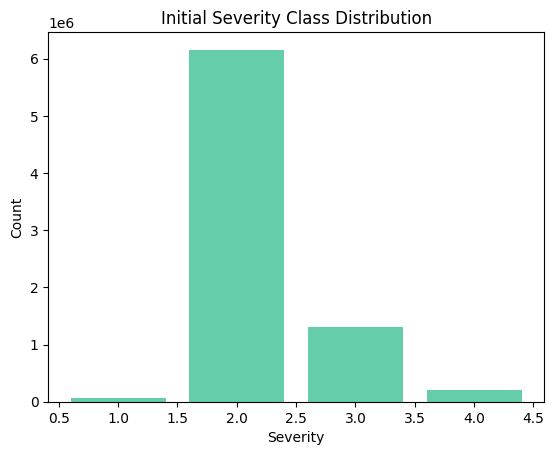

In [10]:
# Checking imbalance in Severity classes
def check_imbalance(df):
    severity_df = df.groupBy("Severity").agg(F.count("*").alias("Count"))

    total_count = severity_df.agg(F.sum("Count")).collect()[0][0]

    severity_df = severity_df.withColumn(
        "Percentage",
        F.round(F.col("Count") / total_count * 100, 5)
        ).orderBy("Severity")

    border("Checking for imbalance")

    # Table
    print()
    border("Table")
    severity_df.show()

    # Barplot
    severity_pd = severity_df.toPandas()
    border("Barplot")
    plt.figure()
    plt.title("Initial Severity Class Distribution")
    plt.bar(severity_pd["Severity"], severity_pd["Count"], color="mediumaquamarine")
    plt.xlabel("Severity")
    plt.ylabel("Count")
    plt.show()

check_imbalance(df)

## Check for Duplicates

In [11]:
intital_count = df.count()
df = df.dropDuplicates()
dupe_count = intital_count - df.count()
print(f"Number of duplicate rows dropped: {dupe_count}")

Number of duplicate rows dropped: 117695


## Drop Columns

In [12]:
# Checking for Columns to drop
border("Country and Turning_Loop")
tbl = df.groupBy("Country", "Turning_Loop").count()
tbl.show()

border("Source column")
tbl = df.groupBy("Source").count()
tbl.show()

==================== Country and Turning_Loop ====================
+-------+------------+-------+
|Country|Turning_Loop|  count|
+-------+------------+-------+
|     US|       false|7610699|
+-------+------------+-------+

==================== Source column ====================
+-------+-------+
| Source|  count|
+-------+-------+
|Source2|3303245|
|Source1|4210136|
|Source3|  97318|
+-------+-------+



In [13]:
cols_to_drop = ["Country", "Turning_Loop", "Source", "End_Lat", "End_Lng", "Description", "Wind_Chill(F)"]
df = df.drop(*cols_to_drop)

border("After dropping")
df.printSchema()

==================== After dropping ====================
root
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullab

## Filtering `Distance(mi)`

In [14]:
bef_drop_n = df.count()
df = df.filter(
    (F.col("Distance(mi)") < 20)
)
aft_drop_n = df.count()

border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("\nRows dropped:", bef_drop_n - aft_drop_n)


==================== BEFORE ====================
7610699
==================== AFTER ====================
7602816

Rows dropped: 7883


## Process Time-based Features

### Process Start_Time & End_Time Columns

In [15]:
# Standardise Timestamp
df = (
    df.withColumn("Start_Time", F.to_timestamp(F.col("Start_Time"), "yyyy-MM-dd HH:mm:ss"))
      .withColumn("End_Time", F.to_timestamp(F.col("End_Time"), "yyyy-MM-dd HH:mm:ss"))
      .withColumn("Weather_Timestamp", F.to_timestamp(F.col("Weather_Timestamp"), "yyyy-MM-dd HH:mm:ss"))
)

# Extract: year, month, day_of_week, hour, is_weekend
df = df.withColumns({
    "Start_Time_Year": F.year(F.col("Start_Time")),
    "Start_Time_Month": F.month(F.col("Start_Time")),
    "Start_Time_Day_of_Week": F.dayofweek(F.col("Start_Time")),
    "Start_Time_Hour": F.hour(F.col("Start_Time")),
    "Start_Time_is_Weekend": F.when(F.col("Start_Time_Day_of_Week").isin([1, 7]), 1).otherwise(0),
    "End_Time_Year": F.year(F.col("End_Time")),
    "End_Time_Month": F.month(F.col("End_Time")),
    "End_Time_Day_of_Week": F.dayofweek(F.col("End_Time")),
    "End_Time_Hour": F.hour(F.col("End_Time")),
    "End_Time_is_Weekend": F.when(F.col("End_Time_Day_of_Week").isin([1, 7]), 1).otherwise(0)
})

### Drop Weather_Timestamps

In [16]:
mean_diff = df.select(
    F.mean((F.col("Weather_Timestamp").cast("long") - F.col("Start_Time").cast("long"))).alias("mean_diff_seconds")
).collect()[0]["mean_diff_seconds"]

print(f"Mean difference between 'Start_Time' and 'Weather_Timestamp': {mean_diff} seconds")

Mean difference between 'Start_Time' and 'Weather_Timestamp': 29.57593357614651 seconds


In [17]:
df = df.drop("Weather_Timestamp")

### Create & Process Duration Column

In [18]:
df = df.withColumns({
    "Duration_Seconds": F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time")),
    "Duration_Minutes": (F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time"))) / 60,
    "Duration_Hours": (F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time"))) / 3600
})

df.show(5)

+--------+-------------------+-------------------+------------------+-----------------+------------+--------------------+-----------+--------------+-----+----------+----------+------------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+------------------+------------------+
|Severity|         Start_Time|           End_Time|         Start_Lat|        Start_Lng|Distance(mi)|              Street|       City|        County|State|   Zipcode|  Timezone|Airport_Code|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mp

### Filter Duration Based on a Set Threshold

In [19]:
bef_drop_n = df.count()
df = df.filter(
    (F.col("Duration_Minutes") > 5.0) &
    (F.col("Duration_Hours") <= 288.0)
)
aft_drop_n = df.count()

border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("\nRows dropped:", bef_drop_n - aft_drop_n)

==================== BEFORE ====================
7602816
==================== AFTER ====================
7597533

Rows dropped: 5283


## Standardise Wind_Direction

In [20]:
# Print all unique values and their counts in terms of dict
def get_count(df):
    counts_df = df.groupBy("Wind_Direction").agg(F.count("*").alias("count"))
    counts_dict = {row["Wind_Direction"]: row["count"] for row in counts_df.collect()}
    total_count = df.count()

    return counts_dict, total_count

before_dict, before_total = get_count(df)

border("BEFORE")
print(before_dict)
print("Total count:", before_total)

# Standardise into N, S, E, W, NE, SE, NW, SW, CALM, VAR
df = df.withColumn(
    "Wind_Direction",
    F.when(F.col("Wind_Direction") == "Calm", "CALM")
    .when(F.col("Wind_Direction").isin("North", "NNE", "NNW"), "N")
    .when(F.col("Wind_Direction").isin("East", "ENE", "ESE"), "E")
    .when(F.col("Wind_Direction").isin("South", "SSE", "SSW"), "S")
    .when(F.col("Wind_Direction").isin("West", "WNW", "WSW"), "W")
    .when(F.col("Wind_Direction") == "Variable", "VAR")
    .otherwise(F.col("Wind_Direction"))
)

# Drop remaining null values
df = df.dropna(subset="Wind_Direction")

after_dict, after_total = get_count(df)

print()
border("AFTER")
print(after_dict)
print("Total count:", after_total)
print("\nRow dropped:", before_total - after_total)

==================== BEFORE ====================
{'VAR': 246176, None: 170309, 'SSE': 343665, 'N': 299818, 'S': 411620, 'CALM': 937110, 'SE': 290147, 'West': 164157, 'ESE': 263869, 'South': 176830, 'WNW': 372428, 'SW': 359258, 'East': 103159, 'Calm': 367437, 'W': 376099, 'NNW': 327402, 'Variable': 113656, 'NNE': 250711, 'North': 152894, 'NW': 362705, 'WSW': 348667, 'E': 272316, 'SSW': 379201, 'NE': 254093, 'ENE': 253806}
Total count: 7597533

==================== AFTER ====================
{'VAR': 359832, 'N': 1030825, 'S': 1311316, 'CALM': 1304547, 'SE': 290147, 'SW': 359258, 'W': 1261351, 'NW': 362705, 'E': 893150, 'NE': 254093}
Total count: 7427224

Row dropped: 170309


## Split

In [21]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

## Handle missing values

- Impute missing values for:
  1. Temperature(F)
  2. Humidity(%)
  3. Pressure(in)
  4. Visibility(mi)
  5. Wind_Speed(mph)
  6. Precipitation(in)

In [22]:
# Create list of weather data
weather = ["Temperature(F)","Humidity(%)","Pressure(in)","Visibility(mi)","Wind_Speed(mph)", "Precipitation(in)"]

# Print missing values from weather data
def show_missing_weather(df, df_name):
    border(df_name)
    df.select([
        F.sum((F.col(c).isNull() | F.isnan(F.col(c))).cast("int")).alias(c)
        for c in weather
    ]).show()

# Impute missing values with median based on Airport_Code and Start_Time_Month
median_df = train_df.groupBy("Airport_Code", "Start_Time_Month").agg(
    *[F.median(F.col(c)).alias(f"{c}_median") for c in weather]
)

def impute_weather(df):
    df = df.join(median_df, on=["Airport_Code", "Start_Time_Month"], how="left")
    for c in weather:
        df = df.withColumn(c, F.coalesce(F.col(c), F.col(f"{c}_median")))
    df = df.drop(*[f"{c}_median" for c in weather])
    df = df.dropna(subset=weather)
    return df


show_missing_weather(train_df, "train_df BEFORE")
show_missing_weather(test_df, "test_df BEFORE")

train_df = impute_weather(train_df)
test_df = impute_weather(test_df)

print()
show_missing_weather(train_df, "train_df AFTER")
show_missing_weather(test_df, "test_df AFTER")

==================== train_df BEFORE ====================
+--------------+-----------+------------+--------------+---------------+-----------------+
|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Speed(mph)|Precipitation(in)|
+--------------+-----------+------------+--------------+---------------+-----------------+
|         25623|      33496|       11782|         32640|         316079|          1656962|
+--------------+-----------+------------+--------------+---------------+-----------------+

==================== test_df BEFORE ====================
+--------------+-----------+------------+--------------+---------------+-----------------+
|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Speed(mph)|Precipitation(in)|
+--------------+-----------+------------+--------------+---------------+-----------------+
|          6321|       8334|        2883|          8058|          78822|           414762|
+--------------+-----------+------------+--------------+---------

## Drop Remaining NA rows

In [23]:
# Drop NA rows for City, Zipcode, Airport_Code, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight
subset_cols = ['City', 'Zipcode', 'Airport_Code', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Street', 'Weather_Condition']

def drop_na_rows(df, df_name):
    bef_count = df.count()
    df = df.dropna(subset=subset_cols)
    print(f"{df_name} rows dropped: {bef_count - df.count()}")
    return df

train_df = drop_na_rows(train_df, "train_df")
test_df = drop_na_rows(test_df, "test_df")

train_df rows dropped: 47547
test_df rows dropped: 11794


## Drop Columns After Investigation

In [24]:
def drop_cols(df, df_name):
    end_time_cols = [c for c in df.columns if c.startswith("End_Time")]
    duration_cols = [c for c in df.columns if c.startswith("Duration")]
    other_cols = ["Distance(mi)", "Amenity", "Bump", "Give_Way", "No_Exit", "Railway", "Roundabout", "Traffic_Calming"]

    all_cols = end_time_cols + duration_cols + other_cols

    print(f"{df_name} dropping: {all_cols}")
    df = df.drop(*all_cols)
    return df

train_df = drop_cols(train_df, "train_df")
test_df = drop_cols(test_df, "test_df")

train_df dropping: ['End_Time', 'End_Time_Year', 'End_Time_Month', 'End_Time_Day_of_Week', 'End_Time_Hour', 'End_Time_is_Weekend', 'Duration_Seconds', 'Duration_Minutes', 'Duration_Hours', 'Distance(mi)', 'Amenity', 'Bump', 'Give_Way', 'No_Exit', 'Railway', 'Roundabout', 'Traffic_Calming']
test_df dropping: ['End_Time', 'End_Time_Year', 'End_Time_Month', 'End_Time_Day_of_Week', 'End_Time_Hour', 'End_Time_is_Weekend', 'Duration_Seconds', 'Duration_Minutes', 'Duration_Hours', 'Distance(mi)', 'Amenity', 'Bump', 'Give_Way', 'No_Exit', 'Railway', 'Roundabout', 'Traffic_Calming']


## Binarise Severity (Target Variable)

In [25]:
train_df = train_df.withColumn("high_severity", (F.col("Severity") >= 3).cast("int"))
test_df = test_df.withColumn("high_severity", (F.col("Severity") >= 3).cast("int"))

## Check for Duplicates

In [26]:
def drop_final_dupes(df, df_name):
    count = df.count()
    df = df.dropDuplicates(subset=["Start_Time", "Start_Lat", "Start_Lng", "Street"])
    print(f"{df_name} duplicate rows dropped: {count - df.count()}")
    return df

train_df = drop_final_dupes(train_df, "train_df")
test_df = drop_final_dupes(test_df, "test_df")

train_df duplicate rows dropped: 268879
test_df duplicate rows dropped: 20974


## End of Cleaning

### Check for Target Variable Imbalance

==================== train_df ====================
==================== Checking for imbalance ====================

==================== Table ====================
+--------+-------+----------+
|Severity|  Count|Percentage|
+--------+-------+----------+
|       1|  49663|   0.90399|
|       2|4338613|  78.97356|
|       3| 977974|  17.80156|
|       4| 127504|   2.32089|
+--------+-------+----------+

==================== Barplot ====================


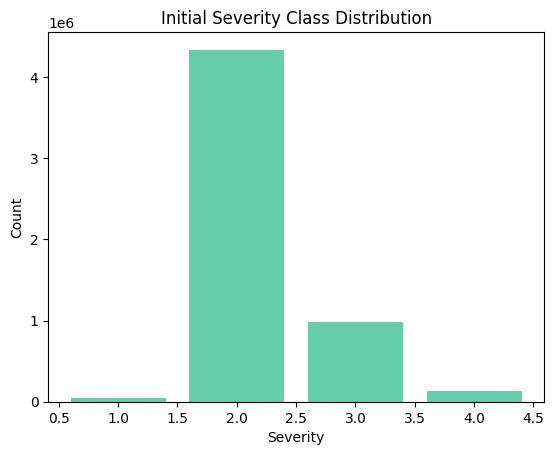


==================== test_df ====================
==================== Checking for imbalance ====================

==================== Table ====================
+--------+-------+----------+
|Severity|  Count|Percentage|
+--------+-------+----------+
|       1|  12345|   0.86854|
|       2|1128073|  79.36597|
|       3| 245637|  17.28188|
|       4|  35301|   2.48361|
+--------+-------+----------+

==================== Barplot ====================


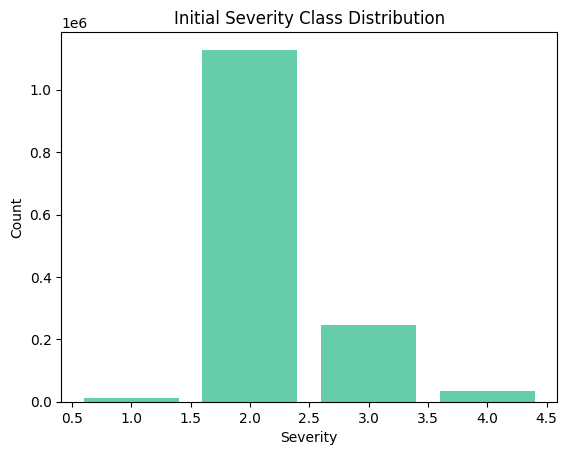

In [27]:
border("train_df")
check_imbalance(train_df)

print()
border("test_df")
check_imbalance(test_df)

### Check for missing values

In [28]:
check_missing("train_df", train_df)
check_missing("test_df", test_df)

==================== Missing values in train_df ====================
+------------+----------------+--------+----------+---------+---------+------+----+------+-----+-------+--------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+--------+--------+-------+----+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------------+---------------+---------------------+-------------+
|Airport_Code|Start_Time_Month|Severity|Start_Time|Start_Lat|Start_Lng|Street|City|County|State|Zipcode|Timezone|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Crossing|Junction|Station|Stop|Traffic_Signal|Sunrise_Sunset|Civil_Twilight|Nautical_Twilight|Astronomical_Twilight|Start_Time_Year|Start_Time_Day_of_Week|Start_Time_Hour|Start_Time_is_Weekend|high_severity|
+------------+----------------+--------+-----

### Print Metrics

In [29]:
# Print metrics
def print_metrics(df, df_name):
    border(f"Cleaned {df_name} schema")
    df.printSchema()

    print()
    border("First 5 rows")
    df.show(5)

    print()
    border("Number of rows")
    row_count = df.count()
    print(row_count)

    border("Number of columns")
    col_count = df.columns
    print(len(col_count))

print_metrics(train_df, "train_df")
print_metrics(test_df, "test_df")

==================== Cleaned train_df schema ====================
root
 |-- Airport_Code: string (nullable = true)
 |-- Start_Time_Month: integer (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullable = true)
 |-- Crossing: boolean (nullable = true)
 |-- Junction: boolean (nulla

## Download Cleaned Data as Parquet

In [30]:
def save_parquet(df, path):
    path.mkdir(parents=True, exist_ok=True)
    df.write.mode("overwrite").parquet(str(path))
    print(f"Successfully written: {path}")

PROJECT_ROOT = Path.cwd().parent
TRAIN_PARQUET_PATH = PROJECT_ROOT / "dataset" / "train_parquet"
TEST_PARQUET_PATH = PROJECT_ROOT / "dataset" / "test_parquet"

save_parquet(train_df, TRAIN_PARQUET_PATH)
save_parquet(test_df, TEST_PARQUET_PATH)

Successfully written: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\train_parquet
Successfully written: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\test_parquet


In [31]:
spark.stop()